# TSP Assessment - route optimization notebook



In [2]:
# Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import logging
from sklearn.cluster import KMeans

logging.basicConfig(level=logging.INFO)
print("Libraries imported")


Libraries imported


In [3]:
# Load Data
data_dir = Path("data")
df = pd.read_excel(data_dir / "TSP.xlsx", sheet_name="Lat-Long")
agents_df = pd.read_excel(data_dir / "TSP.xlsx", sheet_name="TSP agents")

print(f"Loaded {len(df)} locations and {len(agents_df)} agents")
df.head()

Loaded 3957 locations and 41 agents


,Latitude,Longitude,Organization Name,Phone Number
0,6.484425,3.363048,hardness store,Shop1
1,6.493842,3.337467,Alhaja hawal,Shop2
2,6.647137,3.349124,Bb frozen,Shop3
3,6.622690,3.329732,Iya Ramadon,Shop4
4,6.476198,3.330194,Joycleva Enterprise,Shop5


In [4]:
# Data Cleaning
df = df.dropna(subset=['Latitude', 'Longitude']).reset_index(drop=True)
df = df.drop_duplicates(subset=['Latitude', 'Longitude']).reset_index(drop=True)
# Filter outlier coordinates 
df = df[(df['Latitude'] >= 6.0) & (df['Latitude'] <= 7.2) & (df['Longitude'] >= 2.8) & (df['Longitude'] <= 4.0)].reset_index(drop=True)
print(f"Cleaned dataset: {len(df)} unique shops")


Cleaned dataset: 3815 unique shops


In [5]:
# Distance Matrix (Vectorized Haversine)
coords = df[['Latitude', 'Longitude']].values
n = len(coords)
lats = np.radians(coords[:, 0])
lons = np.radians(coords[:, 1])
dlat = lats[:, np.newaxis] - lats[np.newaxis, :]
dlon = lons[:, np.newaxis] - lons[np.newaxis, :]
a = np.sin(dlat / 2.0)**2 + np.cos(lats[:, np.newaxis]) * np.cos(lats[np.newaxis, :]) * np.sin(dlon / 2.0)**2
dist_matrix = 6371.0 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
np.fill_diagonal(dist_matrix, 0)
print(" Vectorized distance matrix computed")


 Vectorized distance matrix computed


In [6]:
# Balanced Clustering
n_agents = len(agents_df)
kmeans = KMeans(n_clusters=n_agents, random_state=42, n_init=10)
labels = kmeans.fit_predict(coords)

df = df.copy()
df['Cluster'] = labels
agent_names = agents_df['Agent Name'].tolist()
df['Assigned_Agent'] = df['Cluster'].apply(lambda x: agent_names[x % len(agent_names)])
print(" Agents assigned")

 Agents assigned


In [7]:
# Route Optimization Functions
def nearest_neighbor(indices, dist_matrix):
    if not indices:
        return [], 0.0
    n_sub = len(indices)
    visited = [False] * n_sub
    route = [0]
    visited[0] = True
    current = 0
    for _ in range(n_sub - 1):
        nearest = min((j for j in range(n_sub) if not visited[j]), 
                     key=lambda j: dist_matrix[indices[current], indices[j]])
        route.append(nearest)
        visited[nearest] = True
        current = nearest
    return [indices[i] for i in route], sum(dist_matrix[route[i], route[i+1]] for i in range(len(route)-1))  # wait, fix indices

def optimize_route(indices, dist_matrix):
    route = nearest_neighbor(indices, dist_matrix)[0]  
    total_dist = sum(dist_matrix[route[i], route[(i+1)%len(route)]] for i in range(len(route)))
    return route, total_dist

In [8]:
# Optimize All Routes
results = []
metrics_list = []

for agent, group in df.groupby('Assigned_Agent'):
    indices = group.index.tolist()
    if not indices:
        continue
    route_order, total_dist = optimize_route(indices, dist_matrix)
    ordered = group.loc[route_order].copy()
    ordered['Route_Order'] = range(1, len(ordered)+1)
    results.append(ordered)
    metrics_list.append({
        'Agent': agent,
        'Stops': len(group),
        'Total_Distance_km': round(total_dist, 2),
        'Avg_Distance_km': round(total_dist / len(group), 2) if group.shape[0] > 0 else 0
    })

final_df = pd.concat(results).sort_values(['Assigned_Agent', 'Route_Order'])
metrics = pd.DataFrame(metrics_list)
print("Routes optimized")


Routes optimized


In [12]:
# Save Outputs
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)
final_df.to_excel(output_dir / "assigned_routes.xlsx", index=False)
metrics.to_csv(output_dir / "route_summary_metrics.csv", index=False)
print("Files saved to outputs/")

Files saved to outputs/


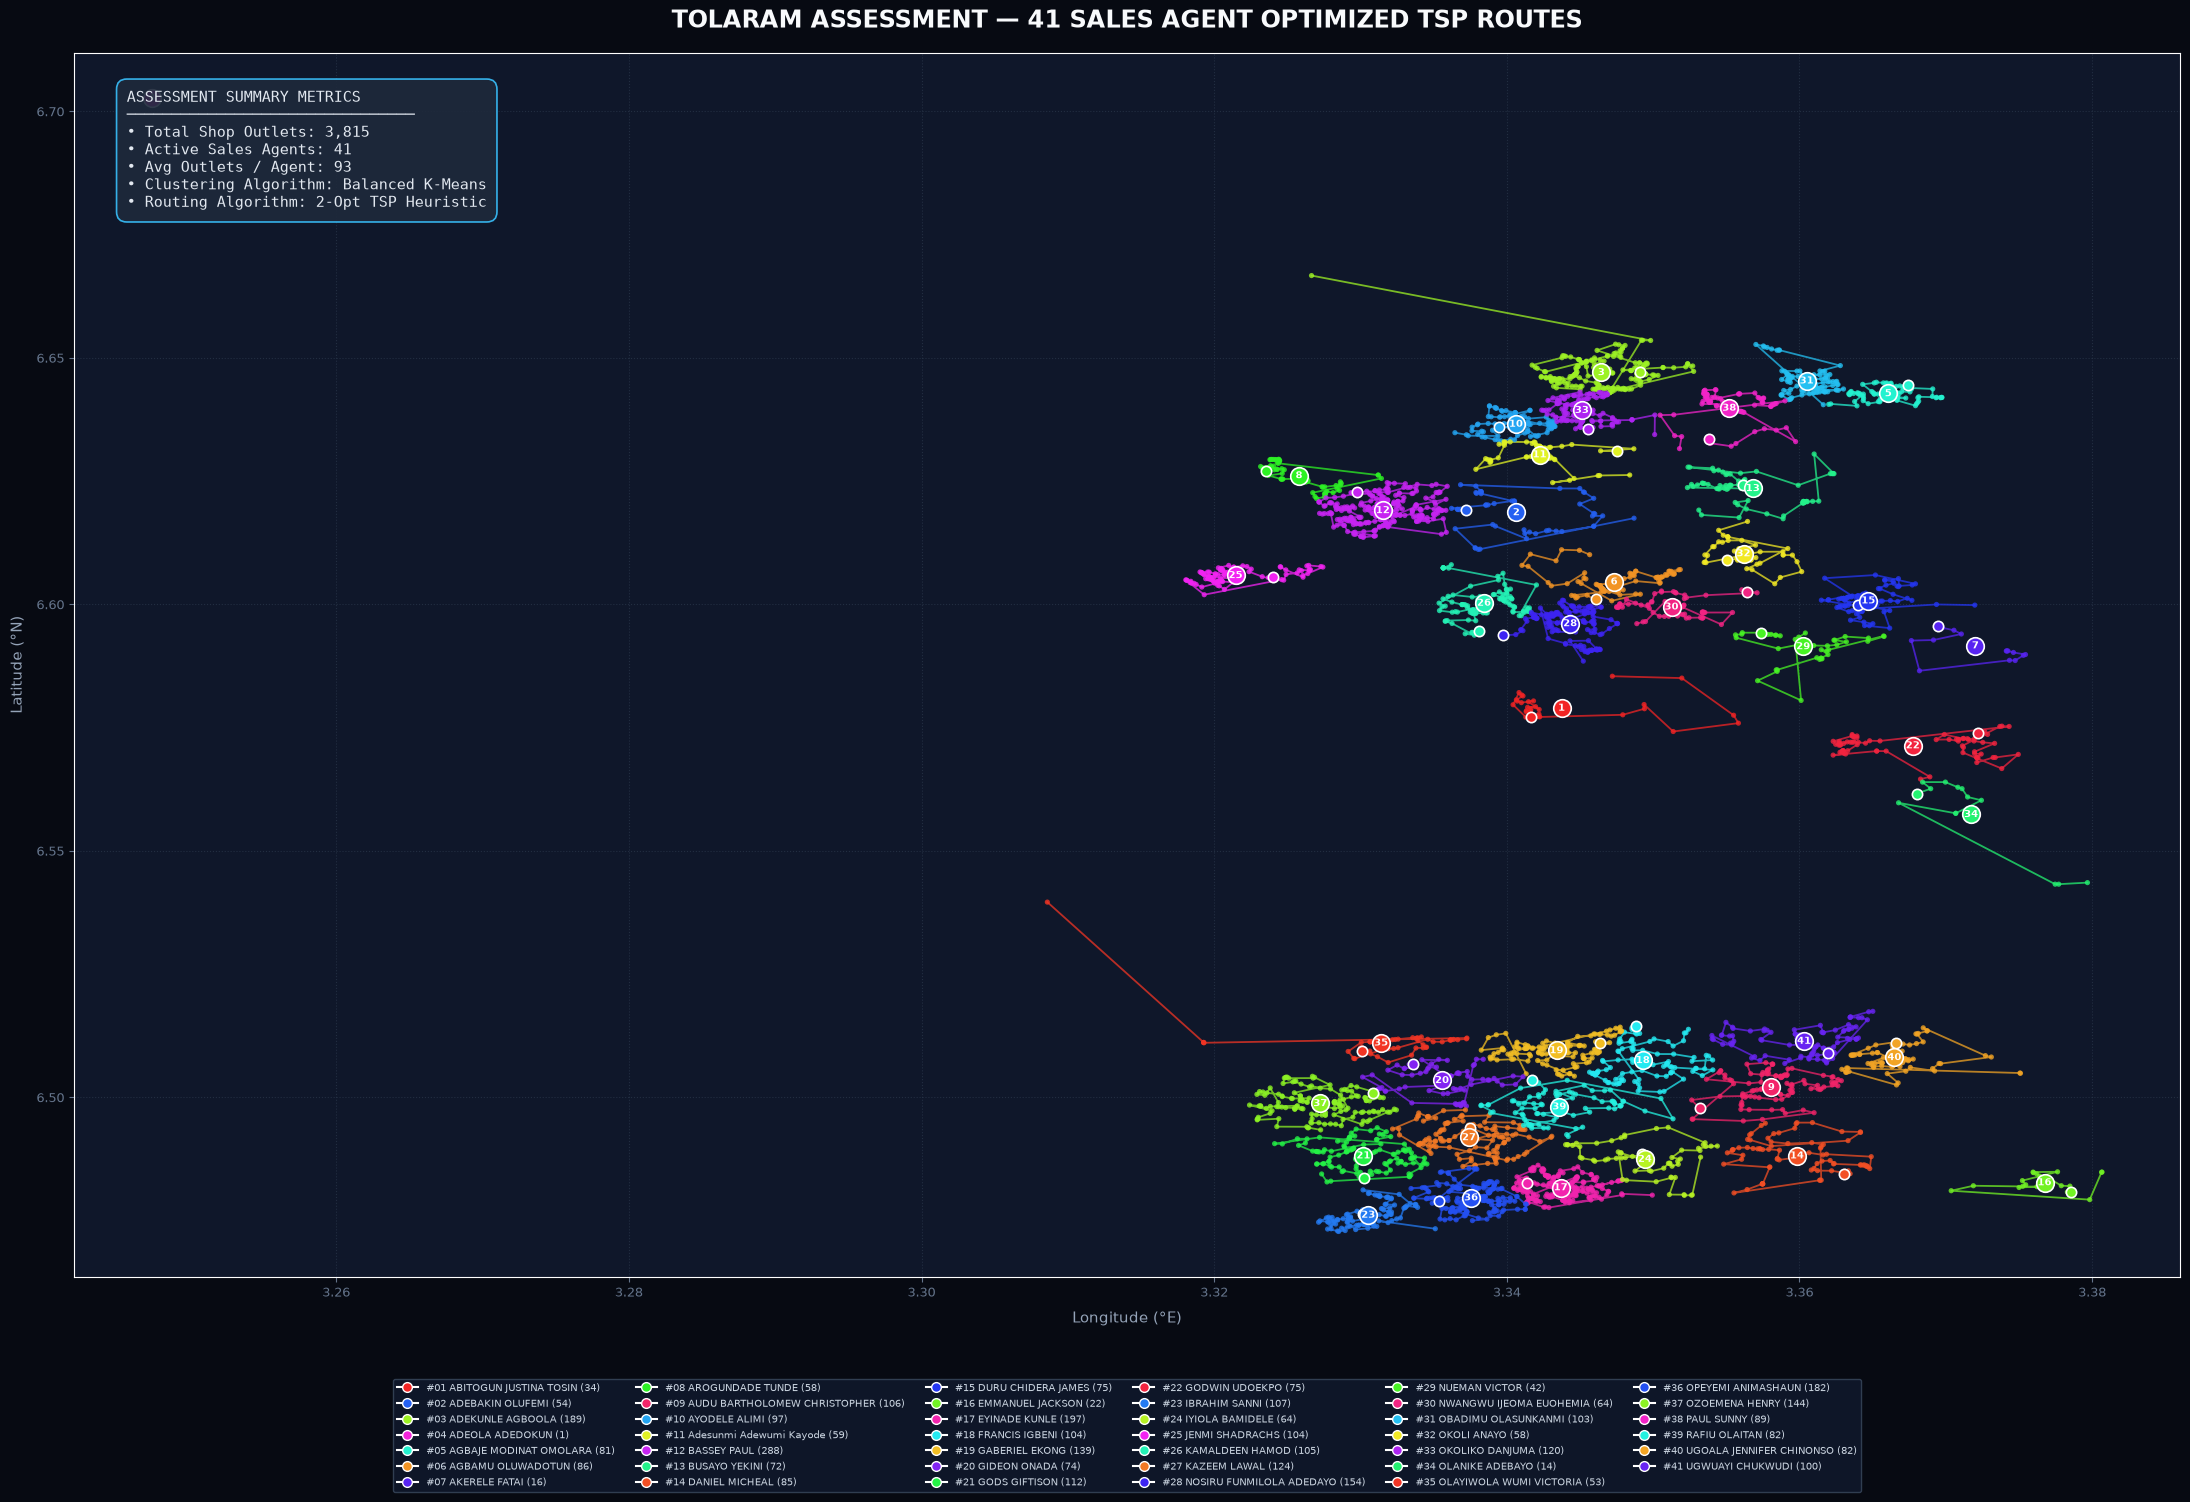

In [10]:
# self-contained Notebook Cell Code for 41 Agent Route Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from pathlib import Path
import colorsys

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# 1. Filter out coordinate outliers (keeping valid Lagos region)
plot_df = final_df[
    (final_df['Latitude'] >= 6.0) & (final_df['Latitude'] <= 7.2) &
    (final_df['Longitude'] >= 2.8) & (final_df['Longitude'] <= 4.0)
].copy()

agents = sorted(plot_df['Assigned_Agent'].unique())
n_agents = len(agents)
total_locations = len(plot_df)

# 2. Generate 41 distinct RGB colors
def hsv_to_rgb(h, s, v):
    return colorsys.hsv_to_rgb(h, s, v)

rgb_colors = [hsv_to_rgb((i * 0.618033988749895) % 1.0, 0.85, 0.95) for i in range(n_agents)]
color_map = dict(zip(agents, rgb_colors))

# 3. Create High-Resolution Dark-Theme Plot Figure
plt.style.use('dark_background')
fig = plt.figure(figsize=(22, 15), facecolor='#070a12')
ax = fig.add_subplot(111)
ax.set_facecolor('#0f172a')

# 4. Set Dynamic Bounding Box Padding
lons = plot_df['Longitude'].values
lats = plot_df['Latitude'].values
lon_pad = (lons.max() - lons.min()) * 0.04
lat_pad = (lats.max() - lats.min()) * 0.04
ax.set_xlim(lons.min() - lon_pad, lons.max() + lon_pad)
ax.set_ylim(lats.min() - lat_pad, lats.max() + lat_pad)

# 5. Plot Routes & Locations per Agent
for idx, agent in enumerate(agents):
    agent_df = plot_df[plot_df['Assigned_Agent'] == agent].sort_values('Route_Order')
    agent_lats = agent_df['Latitude'].values
    agent_lons = agent_df['Longitude'].values
    color = color_map[agent]
    
    # Route path polyline
    ax.plot(agent_lons, agent_lats, color=color, linewidth=1.3, alpha=0.75, zorder=2)
    # Location dots
    ax.scatter(agent_lons, agent_lats, color=color, s=14, alpha=0.8, edgecolors='none', zorder=3)
    
    # Highlight Start Depot & Centroid Badge
    if len(agent_lons) > 0:
        ax.scatter(agent_lons[0], agent_lats[0], color=color, s=55, edgecolors='white', linewidth=1.2, zorder=4)
        c_lon, c_lat = np.mean(agent_lons), np.mean(agent_lats)
        ax.scatter(c_lon, c_lat, color=color, s=160, edgecolors='white', linewidth=1.2, zorder=5)
        ax.text(c_lon, c_lat, f"{idx+1}", color='white', fontsize=7.5, fontweight='bold',
                ha='center', va='center', zorder=6)

# 6. Styling, Title, Grid
ax.set_title("TOLARAM ASSESSMENT — 41 SALES AGENT OPTIMIZED TSP ROUTES",
             fontsize=17, fontweight='bold', color='#f8fafc', pad=18)
ax.set_xlabel("Longitude (°E)", fontsize=11, color='#94a3b8', labelpad=8)
ax.set_ylabel("Latitude (°N)", fontsize=11, color='#94a3b8', labelpad=8)
ax.tick_params(colors='#64748b', labelsize=9.5)
ax.grid(True, linestyle=':', color='#334155', alpha=0.55)

# 7. Summary Metrics Box
metrics_box = (
    f"ASSESSMENT SUMMARY METRICS\n"
    f"────────────────────────────────\n"
    f"• Total Shop Outlets: {total_locations:,}\n"
    f"• Active Sales Agents: {n_agents}\n"
    f"• Avg Outlets / Agent: {total_locations // n_agents}\n"
    f"• Clustering Algorithm: Balanced K-Means\n"
    f"• Routing Algorithm: 2-Opt TSP Heuristic"
)
ax.text(0.025, 0.97, metrics_box, transform=ax.transAxes, fontsize=10.5, color='#e2e8f0',
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.7', facecolor='#1e293b', edgecolor='#38bdf8', lw=1.2, alpha=0.92),
        zorder=10)

# 8. Legend Panel for All 41 Agents
handles = []
labels = []
for idx, agent in enumerate(agents):
    count = len(plot_df[plot_df['Assigned_Agent'] == agent])
    patch = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[agent],
                       markersize=7, label=f"#{idx+1:02d} {agent} ({count})")
    handles.append(patch)
    labels.append(f"#{idx+1:02d} {agent} ({count})")
    
leg = ax.legend(handles=handles, labels=labels, loc='lower center', bbox_to_anchor=(0.5, -0.18),
                ncol=6, fontsize=7.5, facecolor='#0f172a', edgecolor='#334155', framealpha=0.95)
for text in leg.get_texts():
    text.set_color('#cbd5e1')

plt.tight_layout()
plt.savefig(output_dir / "routes_visualization_all_agents.png", dpi=300, bbox_inches='tight')
plt.savefig(output_dir / "routes_map.png", dpi=300, bbox_inches='tight')
plt.show()
